# Assignment 3

## Choosing a School: A Personal Perspective on Student Growth

As a parent of a fourth-grade son, choosing the right school is a decision that feels both immediate and long-term. I am considering a move back to Berrien County, where I previously worked as a teacher. I want to make a data-informed choice about where my child will thrive.

A common approach to evaluating schools is to look at test scores or rankings. However, these measures often reflect where students are, not how much they are improving. Growth matters just as much as current performance, if not more.

This project focuses on student growth data from Michigan public schools to better understand which schools are helping students improve over time. By analyzing Mean Student Growth Percentile (MeanSGP), I can compare how schools support academic progress rather than just static achievement.

This analysis explores three key questions to evaluate school quality and make an informed decision about my child’s education: Which schools in Berrien County show strong student growth for a selected grade and subject today? Are these patterns consistent over time? And do these schools continue to support student growth across different grades and student groups? While the initial focus is on finding the best option for a fourth-grade student, the dashboard is designed to support broader exploration across grade levels and populations.


### Data

The data can be found here: https://www.mischooldata.org/k-12-data-files/.  I chose Berrien RESA, all districts, all schools, and the last three school years (2022-2025), and Assessment and Accountability.  See screenshot below.  The csv files were then emailed to me, and I saved them locally.

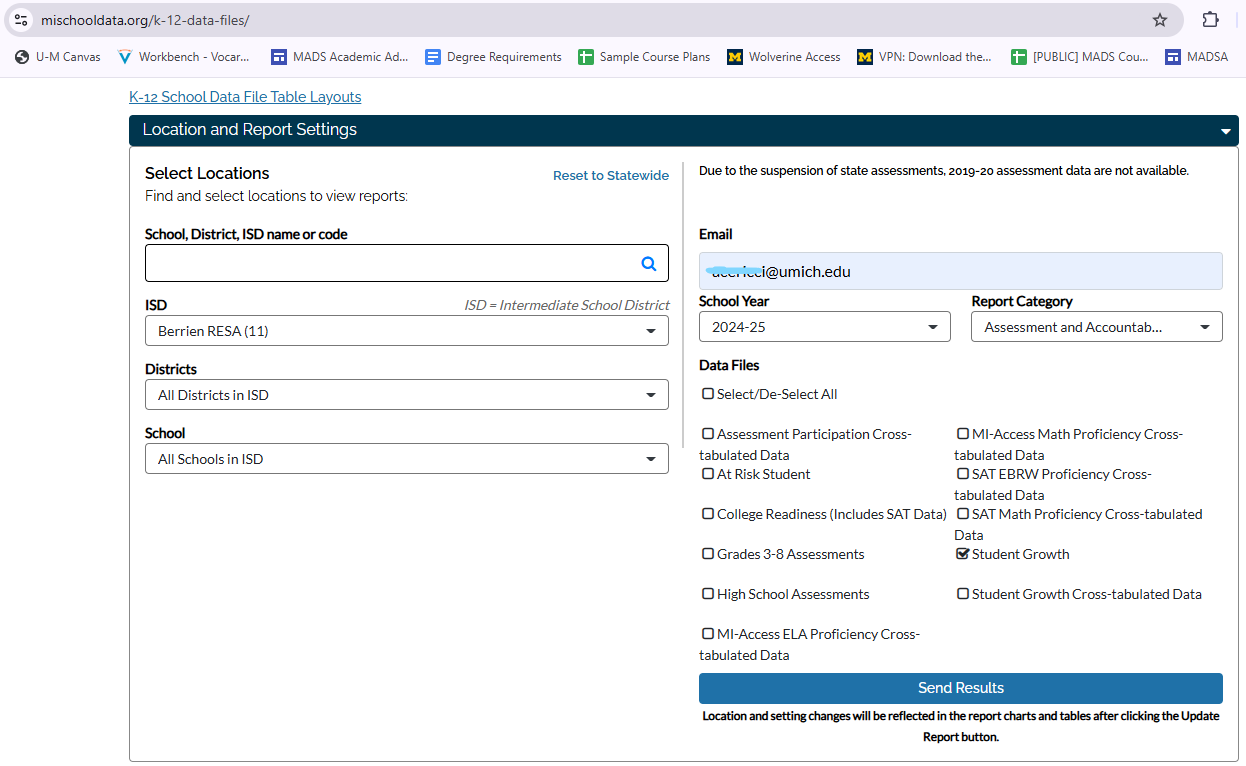

In [48]:
# imports
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

In [2]:
# Let's load our data and get a feel for what our data looks like 
# and if the columns match
df2425 = pd.read_csv('BC School Growth Data 2425.csv')
df2324 = pd.read_csv('BC School Growth Data 2324.csv')
df2223 = pd.read_csv('BC School Growth Data 2223.csv')


In [3]:
df2425.columns == df2324.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [4]:
df2425.columns == df2223.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [5]:
df = pd.concat([df2425, df2324, df2223], ignore_index=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34635 entries, 0 to 34634
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   SchoolYear                34635 non-null  object
 1   IsdCode                   34635 non-null  int64 
 2   IsdName                   34635 non-null  object
 3   DistrictCode              34635 non-null  int64 
 4   DistrictName              34635 non-null  object
 5   BuildingCode              34635 non-null  int64 
 6   BuildingName              34635 non-null  object
 7   CountyCode                34635 non-null  int64 
 8   CountyName                34635 non-null  object
 9   EntityType                34635 non-null  object
 10  SchoolLevel               34635 non-null  object
 11  Locale                    34635 non-null  object
 12  MISTEM_NAME               34635 non-null  object
 13  MISTEM_CODE               34635 non-null  int64 
 14  Grade                 

The dataset contains over 34,000 observations at the school (building) level, with variables describing school identifiers, grade levels, subjects, and student growth metrics. Several columns that represent numeric values, such as percentages and growth counts are being stored as text (object type). This is a common issue that must be addressed before performing analysis or creating visualizations.

In [7]:
# I need to convert the data types to numeric to use them properly in my analysis
cols_to_convert = [
    'NumberAboveAverageGrowth',
    'NumberAverageGrowth',
    'NumberBelowAverageGrowth',
    'PercentAboveAverage',
    'PercentAverageGrowth',
    'PercentBelowAverage',
    'TotalIncluded',
    'MeanSGP'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce') # coerce the errors

We now have nulls because of non-numeric values such as "< 10".

In [8]:
df[cols_to_convert].isna().sum()

NumberAboveAverageGrowth    21895
NumberAverageGrowth         18564
NumberBelowAverageGrowth    20876
PercentAboveAverage         13709
PercentAverageGrowth        13359
PercentBelowAverage         13619
TotalIncluded               13335
MeanSGP                     13335
dtype: int64

In [40]:
# My focus in MeanSGP, so I will drop any schools that don't provide it
df = df.dropna(subset=['MeanSGP'])

In [9]:
df['SchoolLevel'].unique()

array(['Elem thru High School', 'Middle_High School', 'High School',
       'Elementary', 'Middle School', 'Elem_Middle School'], dtype=object)

In [10]:
df['TestingGroup'].unique()

array(['All Students', 'Economically Disadvantaged',
       'Not Economically Disadvantaged',
       'Native Hawaiian or Other Pacific Islander',
       'American Indian or Alaska Native',
       'Students without Disabilities', 'Students with Disabilities',
       'Male', 'Asian', 'Two or More Races',
       'White, not of Hispanic origin', 'Hispanic',
       'Black, not of Hispanic origin', 'Not Migrant', 'Migrant',
       'Not English Learners', 'English Learners', 'Female'], dtype=object)

In [11]:
df['SchoolYear'].unique()

array(['24 - 25 School Year', '23 - 24 School Year',
       '22 - 23 School Year'], dtype=object)

In [12]:
# I will make SchoolYear an integer, so it will be easier to use later
df['Year'] = df['SchoolYear'].str[:2].astype(int) + 2000

In [41]:
df['BuildingName'].unique()

array(['All Buildings', 'Lighthouse Education Center',
       'Benton Harbor High School', 'Fair Plain East Elementary',
       'Fair Plain Middle School',
       'Career and Alternative Pathways to Education Center',
       'Brown School', 'Clarke School', 'Lincoln School',
       'St. Joseph High School', 'Upton Middle School',
       'Hollywood Elementary School', 'Lakeshore High School',
       'Lakeshore Middle School', 'Roosevelt Elementary School',
       'Stewart Elementary School', 'River Valley Middle/High School',
       'River Valley Elementary School', 'New Buffalo Senior High School',
       'New Buffalo Elementary School', 'New Buffalo Middle School',
       'Brandywine Elementary School', 'Brandywine Senior High School',
       'Brandywine Innovation Academy', 'Brandywine Middle School',
       'Berrien Springs Middle School', 'Berrien Springs High School',
       'Sylvester Elementary School', 'Berrien Springs Virtual Academy',
       'West Michigan Virtual - Battle Cr

The dataset includes rows labeled "All Buildings," which represent aggregated data across multiple schools. While useful for high-level summaries, these rows are not appropriate for direct comparison with individual schools, so I will remove these rows.

In [42]:
df = df[df['BuildingName'] != 'All Buildings']

In [43]:
df['Grade'].unique()

array(['All Grades', '11', '05', '04', '08', '07', '06'], dtype=object)

Since the first focus of this analysis is selecting a school for a fourth-grade student, the dataset was filtered to include only observations corresponding to Grade 04 for all students.

In [44]:
df4 = df[(df['Grade'] == '04') &
    (df['TestingGroup'] == 'All Students')]
df4.head()

,SchoolYear,IsdCode,IsdName,DistrictCode,DistrictName,BuildingCode,BuildingName,CountyCode,CountyName,EntityType,...,TestingGroup,NumberAboveAverageGrowth,NumberAverageGrowth,NumberBelowAverageGrowth,PercentAboveAverage,PercentAverageGrowth,PercentBelowAverage,TotalIncluded,MeanSGP,Year
1149,24 - 25 School Year,11,Berrien RESA,11010,Benton Harbor Area Schools,1629,Fair Plain East Elementary,11,Berrien,LEA School,...,All Students,23.0,16.0,24.0,36.5,25.4,38.1,63.0,49.4,2024
1194,24 - 25 School Year,11,Berrien RESA,11010,Benton Harbor Area Schools,1629,Fair Plain East Elementary,11,Berrien,LEA School,...,All Students,18.0,26.0,19.0,28.6,41.3,30.2,63.0,48.2,2024
1893,24 - 25 School Year,11,Berrien RESA,11020,St. Joseph Public Schools,422,Brown School,11,Berrien,LEA School,...,All Students,24.0,27.0,16.0,35.8,40.3,23.9,67.0,55.3,2024
1899,24 - 25 School Year,11,Berrien RESA,11020,St. Joseph Public Schools,422,Brown School,11,Berrien,LEA School,...,All Students,24.0,25.0,18.0,35.8,37.3,26.9,67.0,52.8,2024
1942,24 - 25 School Year,11,Berrien RESA,11020,St. Joseph Public Schools,992,Clarke School,11,Berrien,LEA School,...,All Students,24.0,43.0,NaN,32.0,57.3,10.7,75.0,59.6,2024


In [45]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 138 entries, 1149 to 34625
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SchoolYear                138 non-null    object 
 1   IsdCode                   138 non-null    int64  
 2   IsdName                   138 non-null    object 
 3   DistrictCode              138 non-null    int64  
 4   DistrictName              138 non-null    object 
 5   BuildingCode              138 non-null    int64  
 6   BuildingName              138 non-null    object 
 7   CountyCode                138 non-null    int64  
 8   CountyName                138 non-null    object 
 9   EntityType                138 non-null    object 
 10  SchoolLevel               138 non-null    object 
 11  Locale                    138 non-null    object 
 12  MISTEM_NAME               138 non-null    object 
 13  MISTEM_CODE               138 non-null    int64  
 14  Grade     

In [46]:
df4['SchoolLevel'].unique()

array(['Elementary', 'Elem_Middle School', 'Elem thru High School'],
      dtype=object)

In [47]:
df4['Subject'].unique()

array(['English Language Arts', 'Mathematics'], dtype=object)

Let's see what is going on with both subjects, then dive into Math.

# Visualizations

## Boxplot: Comparing Growth Across Subjects

To compare student growth between English Language Arts (ELA) and Mathematics, I created a boxplot to visualize the distribution of Mean Student Growth Percentile (MeanSGP). This visualization highlights differences in the distribution of student growth between subjects, including the median, spread, and presence (or lack of) of outliers. The boxplot provides a broad comparison of how growth varies across the two subjects.


In [21]:
fig_box = px.box(
    df4,
    x='Subject',
    y='MeanSGP',
    title='Distribution of Student Growth by Subject'
)

fig_box.update_layout(height=400, width=600)

fig_box.show()

For the next few visualizations, I will just focus on math (because math is the best and most important subject...JK...or am I?)

### Histogram: Understanding the Distribution of Student Growth

To better understand how schools compare overall, I created a histogram of Mean Student Growth Percentile (MeanSGP). This visualization shows the distribution of student growth across all schools in the dataset.

A vertical reference line at 50 represents the state average growth percentile. This provides a useful benchmark for interpreting the results, as values above 50 indicate above-average growth and values below 50 indicate below-average growth.

The histogram will help contextualize other visualizations by showing how common or rare certain growth levels are. For example, if only a small number of schools achieve very high MeanSGP values, those schools may be particularly strong candidates. Conversely, if most schools cluster around the average, differences between them may be less pronounced.


In [22]:
fig_hist = px.histogram(
    df4[df4['Subject'] == 'Mathematics'],
    x='MeanSGP',
    nbins=20,
    title='Distribution of Student Growth in Math Across Schools'
)

fig_hist.update_layout(
    height=400, width = 500
)

fig_hist.add_vline(
    x=50,
    line_dash="dash",
    annotation_text="State Average (50)",
    annotation_position="top"
)

fig_hist.show()

The distribution of MeanSGP appears approximately normal and almost centered around the state average of 50. This suggests that most schools achieve growth levels close to the average, with relatively few schools demonstrating extremely high or low growth.

## Bar Chart: Comparing Schools by Student Growth

To evaluate which schools are currently supporting strong academic growth for fourth-grade students, I created a bar chart using Mean Student Growth Percentile (MeanSGP) for the most recent school year. Each bar represents a school, allowing for direct comparison across buildings and districts (color coded by district).

By sorting the bars, the chart highlights the highest and lowest performing schools, making it easier to identify strong candidates for further consideration.


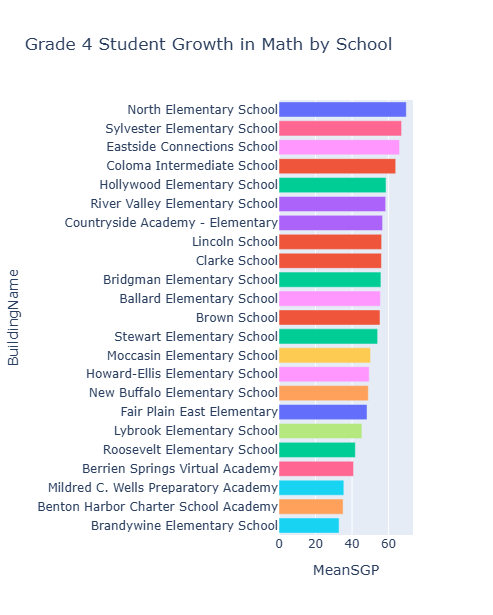

In [23]:
latest_year = df4['Year'].max()

fig_bar = px.bar(
    df4[(df4['Year'] == latest_year) & (df4['Subject'] == 'Mathematics')],
    x='MeanSGP',
    y='BuildingName',
    color='DistrictName',
    orientation='h',
    title='Grade 4 Student Growth in Math by School',
    hover_data=['SchoolYear', 'DistrictName','Subject']
)

fig_bar.update_layout(
    yaxis={'categoryorder':'total ascending'},
    height=600, width=800,
    showlegend=False
)

fig_bar.show()

Let's take a look at the top five schools for growth in math to see their growth over time.  I am looking for consistency, not flukes.

## Line Chart: Evaluating Consistency Over Time

While a single-year comparison provides insight into current performance, it does not capture whether a school’s performance is stable over time. To address this, I created a line chart to track Mean Student Growth Percentile (MeanSGP) over the last three school years.

To maintain clarity, the visualization focuses on a subset of top-performing schools based on the most recent year of data. Each line represents a school, showing how student growth has changed over time.

A reference line at 50 allows for easy identification of schools that consistently perform above or below average.

This visualization is important for long-term decision-making. Schools that demonstrate consistent, above-average growth may provide a more stable and supportive learning environment compared to those with highly variable performance.


In [24]:
top_schools = df4[(df4['Year'] == latest_year) &
    (df4['Subject'] == 'Mathematics')] \
    .nlargest(5, 'MeanSGP')['BuildingName']

df_plot = df4[(df4['Subject'] == 'Mathematics') & (df4['BuildingName'].isin(top_schools))]

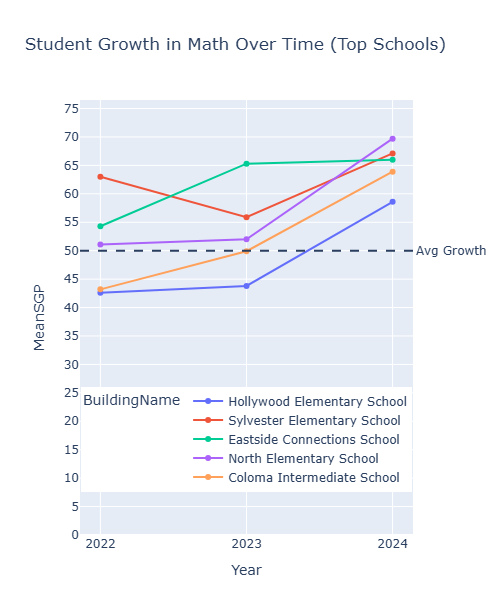

In [25]:
fig = px.line(
    df_plot,
    x='Year',
    y='MeanSGP',
    color='BuildingName',
    markers=True,
    title='Student Growth in Math Over Time (Top Schools)'
)

fig.update_layout(
    height=600,
    width=500
)

fig.update_xaxes(
    tickmode = 'linear',
    tick0 = df4['Year'].min(),
    dtick = 1
)

fig.update_yaxes(
    tickmode = 'linear',
    tick0 = 0,
    dtick = 5,
    range = [0, df4['MeanSGP'].max()]
)

fig.add_hline(
    y=50,
    line_dash="dash",
    annotation_text="Avg Growth",
    annotation_position="right"
)

fig.update_layout(
    legend=dict(
        orientation="h",   # Horizontal orientation
        yanchor="bottom",  # Align the bottom of the legend
        y=0.1,            # Adjust this if it's too close/far (0 is the axis)
        xanchor="center",  # Align the center of the legend
        x=0.5              # 0.5 is the exact middle of the plot
    )
)


fig.show()

I can see that Hollywood and Coloma only surpassed 50% in the most recent year.  Could this be a fluke or a change made in instruction?  Another item of interest is that 4 of the 5 top schools increased from 2023 to  2024.

## Scatter Plot: Exploring the Relationship Between School Size and Growth

To examine whether school size is associated with student growth, I created a scatter plot comparing Total Included (the number of students tested) and Mean Student Growth Percentile (MeanSGP).  Each point represents a school, allowing for the exploration of potential relationships between the number of students and growth outcomes. A reference line at 50 indicates average growth.


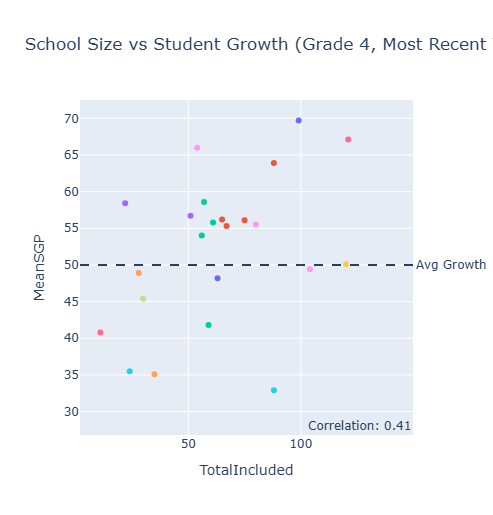

In [26]:
fig_scatter = px.scatter(
    df4[(df4['Year'] == latest_year) & (df4['Subject'] == 'Mathematics')],
    x='TotalIncluded',
    y='MeanSGP',
    color='DistrictName',
    hover_data=['BuildingName'],
    title='School Size vs Student Growth (Grade 4, Most Recent Year)'
)

fig_scatter.update_layout(
    height=500,
    width = 600,
    showlegend=False
)

fig_scatter.add_hline(
    y=50,
    line_dash="dash",
    annotation_text="Avg Growth",
    annotation_position="right"
)

fig_scatter.add_annotation(
    x=max(df4['TotalIncluded']),
    y=min(df4['MeanSGP']),
    text=f"Correlation: 0.41",
    showarrow=False
)
fig_scatter.show()

This visualization helps identify whether larger or smaller schools tend to perform differently, as well as whether variability in growth differs by school size. In this dataset, the relationship appears positive, suggesting that school size may be a strong predictor of student growth.  Let's run a correlation test.

In [27]:
df_corr = df4[
    (df4['Year'] == latest_year) &
    (df4['Subject'] == 'Mathematics')
].dropna(subset=['MeanSGP', 'TotalIncluded'])

corr = df_corr['TotalIncluded'].corr(df_corr['MeanSGP'])
print(f"Correlation between school size and MeanSGP: {corr:.2f}")

Correlation between school size and MeanSGP: 0.41


The resulting correlation coefficient is 0.41, indicating a moderate positive relationship. This suggests that larger schools tend to have slightly higher student growth, though school size alone is not a strong predictor.

# Dashboard

The following dashboard was built using Plotly and ipywidgets, two open-source Python libraries that are well-suited for interactive data visualization in notebook environments. Plotly, developed by Plotly Technologies Inc., provides a high-level, declarative interface for creating interactive charts such as bar charts, line graphs, histograms, and scatter plots, all of which are used in this dashboard. The library is widely adopted in both industry and academia, and can be installed easily using `pip install plotly`. To enable interactivity within the Jupyter notebook environment, ipywidgets was used to create dropdown menus that allow users to dynamically filter the data by subject, grade level, year, and testing group. This approach was chosen over frameworks like Dash due to environment constraints, as the notebook-based setup allows for seamless integration without requiring a separate web server. Plotly’s declarative design simplifies the process of building complex visualizations by focusing on what to display rather than how to render it, though this can limit control in some cases. Additionally, while ipywidgets provides convenient interactivity, it is less scalable and less flexible than full dashboard frameworks like Dash for deployment outside of notebooks. Despite these limitations, the combination of Plotly and ipywidgets offers an effective and accessible solution for building interactive dashboards within a Jupyter environment.


In [88]:
# create the dropdown filters
# I'm allowing multiple variables so the dashboard can be more useful to wider audience

subject_dropdown = widgets.Dropdown(
    options=df['Subject'].unique(),
    value='Mathematics',
    description='Subject:'
)

grade_dropdown = widgets.Dropdown(
    options=sorted(df['Grade'].unique()),
    value='04',
    description='Grade:'
)

year_dropdown = widgets.Dropdown(
    options=sorted(df['Year'].unique()),
    value=df['Year'].max(),
    description='Year:'
)

testing_dropdown = widgets.Dropdown(
    options=sorted(df['TestingGroup'].dropna().unique()),
    value='All Students', 
    description='Group:'
)

In [89]:
out_bar = widgets.Output()
out_line = widgets.Output()
out_hist = widgets.Output()
out_scatter = widgets.Output()

In [154]:
# setting up the plots (similar to above, but for all subjects, grades, years, and groups)

def update_dashboard(subject, grade, year, group):
    df_sub = df[
        (df['Subject'] == subject) &
        (df['Grade'] == grade) &
        (df['TestingGroup'] == group)
    ]

    df_bar = df_sub[df_sub['Year'] == year]

    # Clear outputs (important for grid)
    for out in [out_bar, out_line, out_hist, out_scatter]:
        out.clear_output()

    # --- BAR CHART ---
    with out_bar:
        fig_bar = px.bar(
            df_bar,
            y='BuildingName',
            x='MeanSGP',
            title=f'Performance for {year}',
            orientation='h',
            hover_data=['SchoolYear', 'DistrictName', 'Subject']
        )

        fig_bar.update_layout(
            yaxis={'categoryorder': 'total ascending'},
            height=400,
            width=500,
            showlegend=False
        )

        # Add 50 line
        fig_bar.add_vline(
            x=50,
            line_dash="dash",
            annotation_text="Avg (50)",
            annotation_position="top"
        )

        fig_bar.show()

    # --- LINE CHART ---
    with out_line:
        # Get top 5 schools for selected year
        top_schools = df_bar.nlargest(5, 'MeanSGP')['BuildingName']
        df_line = df_sub[df_sub['BuildingName'].isin(top_schools)]
        
        fig_line = px.line(
            df_line,
            x='Year',
            y='MeanSGP',
            color='BuildingName',
            title='Trend Over Previous 3 Years for Top 5 Schools',
            markers=True
        )
        fig_line.update_xaxes(
            tickmode = 'linear',
            tick0 = df_sub['Year'].min(),
            dtick = 1
        )
        fig_line.update_yaxes(
            tickmode='linear',
            tick0=30,
            dtick=5,
            range=[ df_line['MeanSGP'].min() - 10, df_line['MeanSGP'].max() + 10]
        )

        fig_line.add_hline(
            y=50,
            line_dash="dash",
            annotation_text="Avg (50)",
            annotation_position="right"
        )

        fig_line.update_layout(
            height=400,
            width=400
        )

        fig_line.update_layout(
            legend=dict(
                orientation="h",   # Horizontal orientation
                yanchor="bottom",  # Align the bottom of the legend
                y=-1,            # Adjust this if it's too close/far (0 is the axis)
                xanchor="right",  # Align the center of the legend
                x=1   )           # 0.5 is the exact middle of the plot
        )

        fig_line.show()

    # --- HISTOGRAM ---
    with out_hist:
        fig_hist = px.histogram(
            df_sub,
            x='MeanSGP',
            nbins=15,
            title='Distribution of Growth'
        )

        fig_hist.add_vline(
            x=50,
            line_dash="dash",
            annotation_text="Avg (50)",
            annotation_position="top"
        )

        fig_hist.update_layout(
            height=400,
            width=500
        )

        fig_hist.show()

    # --- SCATTER ---
    with out_scatter:
        df_scatter = df_bar.dropna(subset=['TotalIncluded'])

        fig_scatter = px.scatter(
            df_scatter,
            x='TotalIncluded',
            y='MeanSGP',
            title='Size vs Growth',
            hover_data=['BuildingName']
        )

        fig_scatter.update_layout(
            height=400,
            width=400,
            showlegend=False
        )

        fig_scatter.add_hline(
            y=50,
            line_dash="dash",
            annotation_text="Avg (50)",
            annotation_position="right"
        )

        fig_scatter.show()

In [155]:
# setting up the grid
grid = widgets.GridBox(
    children=[out_bar, out_line, out_hist, out_scatter],
    layout=widgets.Layout(
        grid_template_columns="50% 50%",
        grid_template_rows="500px 500px",
        gap="10px"
    )
)

In [156]:
interactive = widgets.interactive_output(
    update_dashboard,
    {
        'subject': subject_dropdown,
        'grade': grade_dropdown,
        'year': year_dropdown,
        'group': testing_dropdown
    }
)

In [161]:
controls = widgets.HBox(
    [subject_dropdown, grade_dropdown, year_dropdown, testing_dropdown],
    layout=widgets.Layout(flex_flow='row wrap', gap='4px')
)

display(controls, grid, interactive)

GridBox(children=(Output(outputs=({'output_type': 'display_data', 'data': {'application/vnd.plotly.v1+json': {…

Output()

This analysis explores ways to evaluate school quality and make an informed decision about my child’s education: Which schools in Berrien County show strong student growth for a selected grade and subject today? Are these patterns consistent over time? And do these schools continue to support student growth across different grades and student groups? While the initial focus is on finding the best option for a fourth-grade student, the dashboard is designed to support broader exploration across grade levels and populations. I hope you enjoyed and were inspired to make more data based decisions.
